# Imports

In [2]:
import numpy as np
import torch
import math
import matplotlib.pyplot as plt
# SH Coefficients for real spherical harmonics
SH_C0 = 0.28209479177387814
SH_C1 = 0.4886025119029199
SH_C2 = [
	1.0925484305920792,
	-1.0925484305920792,
	0.31539156525252005,
	-1.0925484305920792,
	0.5462742152960396
]
SH_C3 = [
	-0.5900435899266435,
	2.890611442640554,
	-0.4570457994644658,
	0.3731763325901154,
	-0.4570457994644658,
	1.445305721320277,
	-0.5900435899266435
]

def to_numpy(tensor_or_array):
    """
    PyTorch 텐서를 안전하게 NumPy 배열로 변환합니다.
    GPU에 있거나 gradient 계산 그래프에 포함되어 있어도 오류 없이 변환합니다.
    """
    if isinstance(tensor_or_array, torch.Tensor):
        return tensor_or_array.detach().cpu().numpy()
    return np.array(tensor_or_array)


# computeColorsFromSH Python Code

In [3]:
def computeColorFromSH(deg: int, max_coeffs: int, 
                         means: torch.Tensor, campos: torch.Tensor, 
                         shs: torch.Tensor) -> torch.Tensor:
    """
    Args:
        deg: SH 차수 (0 ~ 3)
        max_coeffs: 가우시안 당 최대 SH 계수 개수 (예: deg=3일 때 16)
        means: [3] 크기의 3D 중심점 텐서
        campos: [3] 크기의 카메라 위치 텐서
        shs: [N, max_coeffs, 3] 크기의 SH 계수 텐서 (C++의 1차원 배열을 3차원으로 뷰(view) 처리함)
        clamped: [N, 3] 크기의 클램핑 여부 저장 텐서 (boolean)
    Returns:
        최종 RGB 색상 텐서 [3]
    """
    # 1. 시선 방향(View Direction) 벡터 계산 및 정규화
    pos = means
    dir = pos - campos
    dir = dir / torch.norm(dir)  # glm::length(dir) 대응
    
    # 2. 현재 가우시안의 SH 계수 가져오기
    # C++의 포인터 연산 `shs + idx * max_coeffs`를 파이썬의 인덱싱으로 깔끔하게 처리
    sh = shs
    
    # 기본 색상 (차수 0: 방향에 상관없는 기본 베이스 색상)
    result = SH_C0 * sh[0]
    
    if deg > 0:
        x, y, z = dir[0], dir[1], dir[2]
        result = result - SH_C1 * y * sh[1] + SH_C1 * z * sh[2] - SH_C1 * x * sh[3]
        
        if deg > 1:
            xx, yy, zz = x * x, y * y, z * z
            xy, yz, xz = x * y, y * z, x * z
            
            result = result + \
                SH_C2[0] * xy * sh[4] + \
                SH_C2[1] * yz * sh[5] + \
                SH_C2[2] * (2.0 * zz - xx - yy) * sh[6] + \
                SH_C2[3] * xz * sh[7] + \
                SH_C2[4] * (xx - yy) * sh[8]
                
            if deg > 2:
                result = result + \
                    SH_C3[0] * y * (3.0 * xx - yy) * sh[9] + \
                    SH_C3[1] * xy * z * sh[10] + \
                    SH_C3[2] * y * (4.0 * zz - xx - yy) * sh[11] + \
                    SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * sh[12] + \
                    SH_C3[4] * x * (4.0 * zz - xx - yy) * sh[13] + \
                    SH_C3[5] * z * (xx - yy) * sh[14] + \
                    SH_C3[6] * x * (xx - 3.0 * yy) * sh[15]

    # 3. 색상 값 보정 (0.5 더하기)
    result += 0.5
    #4. 색상 값 클램핑 (0.0 ~ 1.0 범위로 제한)
    # RGB colors are clamped to positive values. If values are
	# clamped, we need to keep track of this for the backward pass.
	# clamped[3 * idx + 0] = (result.x < 0);
	# clamped[3 * idx + 1] = (result.y < 0);
	# clamped[3 * idx + 2] = (result.z < 0);

    # 음수 값을 0으로 자른 최종 색상 반환 (glm::max 대응)
    return torch.clamp(result, min=0.0)

# computeColorFromSH

In `forward.cu`, function used `idx` parameter to specify the gaussian. But in this tutorial, we are going to use a gaussian that is specified below.    
We don't use original function from forward.cu, we use function that is remade by python

In [4]:
deg = 3
max_coeffs = 16 # (opt.max_sh_degree+1)**2 =(3+1)**2 = 16
campos= torch.tensor([ 3.2722,  2.0396, -1.8355], device='cuda:0') #  viewpoint_camera.camera_center
means = torch.tensor([ 4.1741, -1.2869,  9.8939], device='cuda:0') # gaussians._xyz[idx]
shs = torch.tensor([[ 9.7918e-02,  4.7102e-02,  1.5923e-01],
        [ 9.2026e-03,  1.2190e-02, -3.0770e-03],
        [ 4.9639e-03,  6.2247e-03,  3.8908e-04],
        [-6.9768e-05,  1.3472e-03, -3.5958e-03],
        [ 6.3114e-04, -5.9471e-03, -4.5502e-03],
        [ 1.0775e-03,  1.0928e-02, -3.5765e-03],
        [-3.2646e-04,  8.8187e-03, -6.1896e-04],
        [ 3.2580e-03, -9.7573e-04, -1.1050e-02],
        [-6.6485e-03, -8.4350e-03,  2.2616e-02],
        [ 1.3797e-02,  1.2208e-02,  1.9326e-02],
        [-1.9254e-02, -1.8053e-02, -1.9715e-02],
        [ 2.2491e-02,  2.1745e-02,  1.8880e-02],
        [ 2.3299e-02,  2.3384e-02,  1.4558e-02],
        [-1.6225e-02, -1.5055e-02, -1.9556e-02],
        [ 7.2052e-03,  5.6761e-03,  1.7761e-02],
        [ 5.3071e-03,  6.7793e-03, -1.1309e-02]], device='cuda:0')# shs = gaussians._features[idx])

c:\Users\COM\anaconda3\envs\gaussian_splatting\lib\site-packages\torch\cuda\__init__.py:218: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


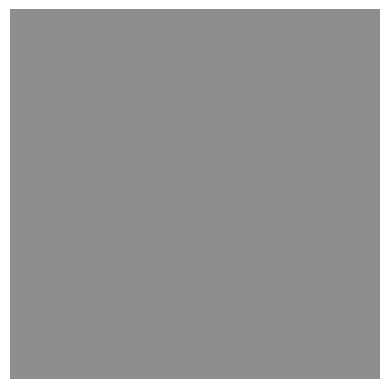

In [5]:
c = computeColorFromSH(deg, max_coeffs, means, campos, shs)
color_pixel=c.cpu().view(1,1,3).numpy()

plt.imshow(color_pixel)
plt.axis('off')
plt.show()

# computeCov3D python code

In [ ]:
def computeCov3D(scale, mod, rot):
    """
    모든 입력은 torch.Tensor 타입 (mod는 스칼라 가능)
    반환값: (6,) 형태의 torch.Tensor (상삼각 요소들)
    """
    # 1. 스케일링 행렬 생성
    S = torch.diag(scale * mod)
    
    # 2. 쿼터니언 성분 추출
    r, x, y, z = rot[0], rot[1], rot[2], rot[3] # COLMAP의 quaternion convention이 q=(w,x,y,z)이다.
    
    # 3. 쿼터니언을 회전 행렬로 변환
    # (Autograd를 안전하게 지원하기 위해 torch.stack 활용)
    R = torch.stack([
        torch.stack([1.0 - 2.0 * (y*y + z*z), 2.0 * (x*y - r*z),       2.0 * (x*z + r*y)]),
        torch.stack([2.0 * (x*y + r*z),       1.0 - 2.0 * (x*x + z*z), 2.0 * (y*z - r*x)]),
        torch.stack([2.0 * (x*z - r*y),       2.0 * (y*z + r*x),       1.0 - 2.0 * (x*x + y*y)])
    ])
    
    # 4. 결합 변환 행렬 M 및 3D 공분산(Sigma) 계산
    M = R @ S
    Sigma = M @ M.T
    
    # 우상단(Upper-right) 6개 요소 반환
    return torch.stack([
        Sigma[0, 0], Sigma[0, 1], Sigma[0, 2],
                     Sigma[1, 1], Sigma[1, 2],
                                  Sigma[2, 2]
    ])

# computeCov3D

In [6]:
scale = torch.tensor([0.0433, 0.1255, 0.0599], device='cuda:0') # gaussians._scale
mod = 1.0 # scaling_modifier =1.0
rot = torch.tensor([0.9896, 0.0519, 0.0849, 0.1035], device='cuda:0') # quaternion

In [9]:
cov3D = computeCov3D(scale, mod, rot)
print(cov3D)

tensor([ 2.4629e-03, -2.6732e-03, -2.7003e-05,  1.5029e-02,  1.4814e-03,
         3.7216e-03], device='cuda:0')


# computeCov2D python code

In [51]:
def computeCov2D(mean, focal_x, focal_y, tan_fovx, tan_fovy, cov3D, viewmatrix):
    """
    모든 입력은 torch.Tensor 타입 (focal, tan 등은 스칼라 또는 스칼라 텐서 허용)
    반환값: (3,) 형태의 torch.Tensor [cov00, cov01, cov11]
    """
    # 1. 뷰 변환 (Transform point 4x3)
    t =  mean@viewmatrix[:3, :3]  + viewmatrix[:3, 3]
    
    # 2. Viewport의 aspect/scaling 경계 제한
    limx = 1.3 * tan_fovx
    limy = 1.3 * tan_fovy
    txtz = t[0] / t[2]
    tytz = t[1] / t[2]
    
    # PyTorch의 clamp 사용
    t_x = torch.clamp(txtz, min=-limx, max=limx) * t[2]
    t_y = torch.clamp(tytz, min=-limy, max=limy) * t[2]
    
    # 3. 투영에 대한 야코비안(Jacobian) 행렬 구성
    # (Autograd를 안전하게 지원하기 위해 빈 텐서에 값을 넣지 않고 torch.stack 활용)
    zero = torch.tensor(0.0, dtype=mean.dtype, device=mean.device)
    
    J = torch.stack([
        torch.stack([focal_x / t[2], zero, -(focal_x * t_x) / (t[2] * t[2])]),
        torch.stack([zero, focal_y / t[2], -(focal_y * t_y) / (t[2] * t[2])]),
        torch.stack([zero, zero, zero])
    ])
    
    # 4. 뷰 매트릭스에서 회전 행렬(W) 추출
    W = viewmatrix[:3, :3]
    
    # 5. 3D 공분산 행렬 복원
    Vrk = torch.stack([
        torch.stack([cov3D[0], cov3D[1], cov3D[2]]),
        torch.stack([cov3D[1], cov3D[3], cov3D[4]]),
        torch.stack([cov3D[2], cov3D[4], cov3D[5]])
    ])
    
    # 6. 2D 공분산 계산
    k = J @ W
    cov = k @ Vrk @ k.T
    
    # 2x2 대칭 행렬의 필요 요소 반환
    return torch.stack([cov[0, 0], cov[0, 1], cov[1, 1]])

In [52]:
mean = means # gaussians._xyz[idx]
tan_fovx = 0.3109704250061455 # math.tan(viewpoint_cam.FoVx*0.5)
tan_fovy = 0.5502673425137008 # math.tan(viewpoint_cam.FoVy*0.5)
width = 1041
height = 1846
focal_x = width / (2.0 * tan_fovx) # this is computed inside the rasterize_impl.cu
focal_y = height / (2.0 * tan_fovy) # this is computed inside the rasterize_impl.cu
cov3D = cov3D
viewmatrix = torch.tensor([[ 0.7348,  0.5511, -0.3954,  0.0000],
                           [-0.5233,  0.8315,  0.1866,  0.0000],
                           [ 0.4316,  0.0698,  0.8993,  0.0000],
                           [-0.5448, -3.3711,  2.5641,  1.0000]], device='cuda:0') #viewpoint_cam.world_view_matrix

In [53]:
cov2D = computeCov2D(mean, focal_x, focal_y, tan_fovx, tan_fovy, cov3D, viewmatrix.T)
print(cov2D)

tensor([111.6159, -93.2253, 198.3034], device='cuda:0')


In [49]:
t =  mean@viewmatrix.T[:3, :3]  + viewmatrix.T[:3, 3]
print(t)

tensor([-2.0989, -4.7793, 13.1734], device='cuda:0')


In [50]:
print(focal_x, focal_y)

1673.7926122386516 1677.3664884119826
